# GIS Data Science Assignment: Climate Change Analysis in Tanzania

In this assignment, you will analyze climate change patterns in Tanzania using GIS data. You will work with spatial data to understand, visualize, and analyze climate trends across different regions of Tanzania.

## Setup
First, let's import the necessary libraries:

In [1]:
# Ensure the following libraries are installed:
# geopandas, matplotlib, numpy, pandas, seaborn, folium, mapclassify, xarray, rasterio, contextily

In [2]:
# Import necessary libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import os
from matplotlib.colors import ListedColormap
import contextily as ctx
from folium.plugins import StripePattern

# Set plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
sns.set(style="whitegrid")

## Part 1: GIS Data Basics

### Task 1.1: Load the Tanzania Shapefile
Load the Tanzania administrative boundaries shapefile and examine its structure.

In [3]:
# TODO: Load the Tanzania shapefile
# Hint: Use gpd.read_file() to load the shapefile
tz_shapefile = gpd.read_file(r"C:\Users\user\Omdena\gis-data-science-carolynewambura06\data\tanzania_regions.shp")

# Function to display basic information about a GeoDataFrame
def describe_geodataframe(gdf):
    """Display basic information about a GeoDataFrame.
    
    Parameters:
    gdf (GeoDataFrame): The GeoDataFrame to describe
    
    Returns:
    dict: A dictionary containing basic information about the GeoDataFrame
    """
    info = {
        'crs': gdf.crs,  # TODO: Get the coordinate reference system
        'geometry_type': gdf.geom_type.unique().tolist(),  # TODO: Get the geometry type
        'num_features': len(gdf),  # TODO: Get the number of features
        'attributes': gdf.columns.tolist(),  # TODO: Get the attribute column names
        'total_area': gdf.to_crs(epsg=6933).geometry.area.sum() / 1e6,  # TODO: Calculate the total area in square kilometers
        'bounds': gdf.total_bounds  # TODO: Get the bounds of the dataset
    }
    return info

# Call the function with your loaded shapefile
tz_info = describe_geodataframe(tz_shapefile)

### Task 1.2: Understand Coordinate Reference Systems
Explain the current CRS and reproject the data to a suitable projection for Tanzania.

In [5]:
# TODO: Identify the current CRS and explain why it might not be optimal for Tanzania
print(tz_shapefile.crs)

# TODO: Reproject the data to a more appropriate CRS for Tanzania
# Hint: Consider using EPSG:21037 (Arc 1960 / UTM zone 37S) which is suitable for Tanzania
tz_projected = tz_shapefile.to_crs(epsg=21037)

# TODO: Compare the original and reprojected data
# Hint: Create a function that compares areas before and after reprojection
def compare_projections(gdf1,gdf2):
    """Compare the original and reprojected GeoDataFrames.
    
    Parameters:
    original_gdf (GeoDataFrame): The original GeoDataFrame
    reprojected_gdf (GeoDataFrame): The reprojected GeoDataFrame
    
    Returns:
    dict: A dictionary containing comparison metrics
    """

    # Calculate total area in both CRS
    original_area = gdf1.to_crs(epsg=6933).geometry.area.sum() / 1e6  # Convert to km²
    new_area = gdf2.geometry.area.sum() / 1e6  # Convert to km²

    # Calculate the percentage difference in area
    percent_difference = ((new_area - original_area) / original_area) * 100

    comparison ={
        'gdf1_crs': gdf1.crs,  # CRS of the first GeoDataFrame
        'gdf2_crs': gdf2.crs,  # CRS of the second GeoDataFrame
        'gdf1_bounds': gdf1.total_bounds.tolist(),  # Bounds of the first GeoDataFrame
        'gdf2_bounds': gdf2.total_bounds.tolist(),   # Bounds of the second GeoDataFrame
        #'original_area': original_area,  # TODO: Calculate the total area in the original projection
        #'new_area': new_area,  # TODO: Calculate the total area in the new projection
        'percent_difference': percent_difference  # TODO: Calculate the percentage difference in area
    }
    return comparison

# Call the comparison function
projection_comparison = compare_projections(tz_shapefile, tz_projected)
print(projection_comparison)


EPSG:4326
{'gdf1_crs': <Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
, 'gdf2_crs': <Projected CRS: EPSG:21037>
Name: Arc 1960 / UTM zone 37S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Kenya - south of equator and east of 36°E; Tanzania - east of 36°E.
- bounds: (36.0, -11.75, 41.6, 0.0)
Coordinate Operation:
- name: UTM zone 37S
- method: Transverse Mercator
Datum: Arc 1960
- Ellipsoid: Clarke 1880 (RGS)
- Prime Meridian: Greenwich
, 'gdf1_bounds': [30.054184691561385, -11.96787177985431, 40.30646215185965, -1.0050755848864366], 'gdf2_bounds': [-489338.8466868056, 8676933.292667741, 644675.4108909741, 9889191.894823829], 'percent_difference': np.float64(0.6864555398592294

## Part 2: Data Loading and Processing

### Task 2.1: Load Climate Data
Load the provided climate data for Tanzania and examine its structure.

In [6]:
# TODO: Load the climate data CSV file
climate_data = pd.read_csv(r"C:\Users\user\Omdena\gis-data-science-carolynewambura06\data\tanzania_annual_climate_data.csv")

# TODO: Display the first few rows and basic statistics of the climate data
# Hint: Use .head(), .describe(), and .info() methods

# Display first few rows
print(climate_data.head())

# Display basic statistics of numeric columns
print(climate_data.describe())

# Display dataset structure (columns, data types, missing values)
print(climate_data.info())


# TODO: Check for missing values and handle them appropriately
def check_missing_values(df):
    """Check for missing values in a DataFrame and return a summary.
   
    Parameters:
    df (DataFrame): The DataFrame to check
    
    Returns:
    DataFrame: A summary of missing values by column
    """
    # TODO: Implement this function
    missing_summary = df.isnull().sum()  # Count missing values per column
    return missing_summary
    

# Check missing values in climate data
missing_summary = check_missing_values(climate_data)
print(missing_summary)

  REGION_CODE REGION_NAME  YEAR      ZONE  ANNUAL_AVG_TEMP_C  MAX_TEMP_C  \
0          AR      Arusha  2000  Northern              21.71       26.60   
1          AR      Arusha  2001  Northern              22.45       27.81   
2          AR      Arusha  2002  Northern              22.81       27.30   
3          AR      Arusha  2003  Northern              21.38       25.77   
4          AR      Arusha  2004  Northern              21.67       26.89   

   MIN_TEMP_C  ANNUAL_PRECIP_MM  ANNUAL_RAIN_DAYS  ANNUAL_HEAVY_RAIN_DAYS  \
0       16.99            6918.2               107                      21   
1       17.78            6333.0               104                      15   
2       17.74           10795.2               144                      41   
3       16.39            5592.0                62                      10   
4       16.57           10407.2               150                      39   

   ANNUAL_DROUGHT_INDEX  ELEVATION_M  DISTANCE_TO_COAST_KM  
0              0.10

### Task 2.2: Join Climate Data with Spatial Data
Merge the climate data with the Tanzania shapefile based on a common identifier.

In [7]:
# TODO: Identify the common field between the climate data and the shapefile
# Hint: Look for a region/district identifier in both datasets
# Inspect the columns in both datasets
print(climate_data.columns)
print(tz_shapefile.columns)


Index(['REGION_CODE', 'REGION_NAME', 'YEAR', 'ZONE', 'ANNUAL_AVG_TEMP_C',
       'MAX_TEMP_C', 'MIN_TEMP_C', 'ANNUAL_PRECIP_MM', 'ANNUAL_RAIN_DAYS',
       'ANNUAL_HEAVY_RAIN_DAYS', 'ANNUAL_DROUGHT_INDEX', 'ELEVATION_M',
       'DISTANCE_TO_COAST_KM'],
      dtype='object')
Index(['REGION_NAM', 'REGION_COD', 'ZONE', 'LAND_AREA_', 'POPULATION',
       'POP_DENSIT', 'ELEVATION_', 'DIST_TO_CO', 'geometry'],
      dtype='object')


In [8]:
# Clean and standardize the fields in both datasets
climate_data['REGION_CODE'] = climate_data['REGION_CODE'].str.strip().str.upper()
tz_shapefile['REGION_COD'] = tz_shapefile['REGION_COD'].str.strip().str.upper()

climate_data['REGION_NAME'] = climate_data['REGION_NAME'].str.strip().str.upper()
tz_shapefile['REGION_NAM'] = tz_shapefile['REGION_NAM'].str.strip().str.upper()

In [9]:
# Aggregate the climate data by REGION_CODE
climate_aggregated = climate_data.groupby('REGION_CODE').agg({
    'ANNUAL_AVG_TEMP_C': 'mean',  # Calculate mean temperature
    'MAX_TEMP_C': 'mean',         # Calculate mean max temperature
    'MIN_TEMP_C': 'mean',         # Calculate mean min temperature
    'ANNUAL_PRECIP_MM': 'mean',   # Calculate mean precipitation
    'ANNUAL_RAIN_DAYS': 'mean',   # Calculate mean rain days
    'ANNUAL_HEAVY_RAIN_DAYS': 'mean',  # Calculate mean heavy rain days
    'ANNUAL_DROUGHT_INDEX': 'mean',    # Calculate mean drought index
    'ELEVATION_M': 'mean',             # Calculate mean elevation
    'DISTANCE_TO_COAST_KM': 'mean'     # Calculate mean distance to coast
}).reset_index()

# Check the result
print(climate_aggregated.shape)  # Should be (31, num_columns)
print(climate_aggregated.head())

(31, 10)
  REGION_CODE  ANNUAL_AVG_TEMP_C  MAX_TEMP_C  MIN_TEMP_C  ANNUAL_PRECIP_MM  \
0          AR          22.330000   27.320417   17.005417       7308.058333   
1          DO          22.178333   27.238333   16.995417       6117.695833   
2          DS          27.510000   32.586667   22.240000       7943.575000   
3          GE          22.882083   27.974167   17.658750      10085.679167   
4          IR          23.940833   29.051250   18.610000      13124.641667   

   ANNUAL_RAIN_DAYS  ANNUAL_HEAVY_RAIN_DAYS  ANNUAL_DROUGHT_INDEX  \
0        102.416667               18.791667              0.520937   
1         84.541667               11.791667              0.384062   
2        110.333333               21.041667              0.603542   
3        134.708333               31.333333              0.353889   
4        162.833333               43.083333              0.334410   

   ELEVATION_M  DISTANCE_TO_COAST_KM  
0        920.2                 469.3  
1       1790.4               

In [10]:
# TODO: Join the climate data with the shapefile
# Hint: Use the merge() or join() method
# Join using REGION_CODE and REGION_COD
# Join the datasets without aggregation
# Join the spatial dataset with the aggregated climate data
tz_climate = tz_shapefile.merge(climate_aggregated, left_on='REGION_COD', right_on='REGION_CODE', how='inner')
print(tz_climate.shape)
print(tz_climate.head())

(31, 19)
      REGION_NAM REGION_COD                ZONE  LAND_AREA_  POPULATION  \
0         ARUSHA         AR            Northern     8238.33      523949   
1  DAR ES SALAAM         DS             Eastern     7765.76      311157   
2         DODOMA         DO             Central    10271.91      784652   
3          GEITA         GE                Lake    11836.41      565591   
4         IRINGA         IR  Southern Highlands    18649.73      214091   

   POP_DENSIT  ELEVATION_  DIST_TO_CO  \
0       63.60       920.2       469.3   
1       40.07      1298.9       257.1   
2       76.39      1790.4       416.6   
3       47.78      1440.9       460.9   
4       11.48       476.1        82.6   

                                            geometry REGION_CODE  \
0  POLYGON ((34.45632 -2.43802, 34.18813 -2.98755...          AR   
1  POLYGON ((38.70825 -1.57788, 38.50566 -2.00984...          DS   
2  POLYGON ((36.45921 -11.0355, 36.2375 -11.44126...          DO   
3  POLYGON ((32.644 -

In [11]:
# TODO: Verify the join was successful by checking the shape and contents of the result
def verify_join(original_gdf, joined_gdf, climate_df):
    """Verify that the join between spatial and climate data was successful.
    
    Parameters:
    original_gdf (GeoDataFrame): The original spatial GeoDataFrame
    joined_gdf (GeoDataFrame): The joined GeoDataFrame
    climate_df (DataFrame): The climate DataFrame
    
    Returns:
    dict: A dictionary containing verification metrics
    """
    verification = {
        'original_features': original_gdf.shape[0],  # Number of features in the original GeoDataFrame
        'joined_features': joined_gdf.shape[0],  # Number of features in the joined GeoDataFrame
        'climate_records': climate_df.shape[0],  # Number of records in the climate DataFrame
        'joined_columns': list(joined_gdf.columns),  # Column names in the joined GeoDataFrame
        'is_successful': (
            joined_gdf.shape[0] > 0 and  # Ensure the joined dataset is not empty
            joined_gdf.shape[0] <= original_gdf.shape[0] and  # Joined features <= original features
            joined_gdf.shape[0] <= climate_df.shape[0] and  # Joined features <= climate records
            all(col in joined_gdf.columns for col in original_gdf.columns) and  # Original columns preserved
            any(col in joined_gdf.columns for col in climate_df.columns)  # At least one climate column added
        )
    }
    return verification

# Example usage
join_verification = verify_join(tz_shapefile, tz_climate, climate_aggregated)
print(join_verification)

{'original_features': 31, 'joined_features': 31, 'climate_records': 31, 'joined_columns': ['REGION_NAM', 'REGION_COD', 'ZONE', 'LAND_AREA_', 'POPULATION', 'POP_DENSIT', 'ELEVATION_', 'DIST_TO_CO', 'geometry', 'REGION_CODE', 'ANNUAL_AVG_TEMP_C', 'MAX_TEMP_C', 'MIN_TEMP_C', 'ANNUAL_PRECIP_MM', 'ANNUAL_RAIN_DAYS', 'ANNUAL_HEAVY_RAIN_DAYS', 'ANNUAL_DROUGHT_INDEX', 'ELEVATION_M', 'DISTANCE_TO_COAST_KM'], 'is_successful': True}


## Part 3: Data Visualization

### Task 3.1: Create a Choropleth Map
Create a choropleth map showing average temperature across Tanzania regions.

In [12]:
# Ensure the CRS is set (e.g., WGS84)
tz_climate.set_crs(epsg=4326, inplace=True)

# Reproject to Web Mercator (EPSG:3857) for better visualization
tz_climate = tz_climate.to_crs(epsg=3857)


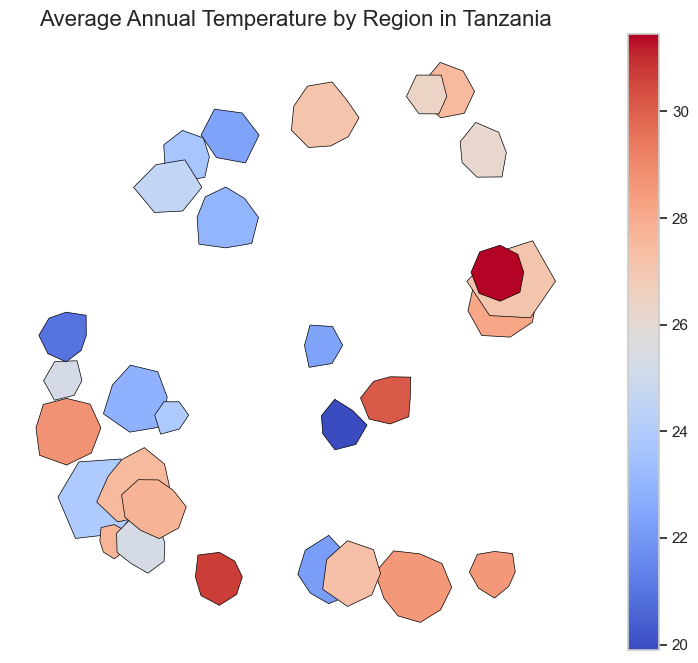

In [13]:
# TODO: Create a choropleth map of average temperature by region
# Hint: Use the .plot() method with the column parameter
def create_choropleth(gdf, column, title, cmap='viridis', figsize=(12, 8)):
    """Create a choropleth map for a GeoDataFrame.
    
    Parameters:
    gdf (GeoDataFrame): The GeoDataFrame to plot
    column (str): The column to use for coloring
    title (str): The title of the map
    cmap (str or Colormap): The colormap to use
    figsize (tuple): The figure size
    
    Returns:
    matplotlib.figure.Figure: The created figure
    """
    # TODO: Implement this function
    # Create the plot
    fig, ax = figsize = plt.subplots(figsize = figsize)
    
    # Plot the choropleth map
    gdf.plot(column=column, cmap=cmap, legend =True, edgecolor='black' , linewidth=0.5, ax =ax)
   
    # Add a title
    ax.set_title(title, fontsize=16)
    
    # Remove axis
    ax.set_axis_off()
    
    # Return the figure
    return fig

# Create the choropleth map
temp_map = create_choropleth(
    gdf=tz_climate,  # The GeoDataFrame with the joined data
    column='ANNUAL_AVG_TEMP_C',  # The column to use for coloring (average temperature)
    title='Average Annual Temperature by Region in Tanzania',  # Title of the map
    cmap='coolwarm',  
    figsize=(12, 8)  # Figure size
)

# Display the map
plt.show()

### Task 3.2: Create a Time Series Visualization
Create a time series visualization showing temperature trends over time for selected regions.

In [14]:
# TODO: Select a few representative regions for the time series
# Hint: Choose regions from different parts of the country
selected_regions = ['ARUSHA', 'DAR ES SALAAM', 'DODOMA', 'MBEYA', 'MOROGORO']

# Filter the original climate data for the selected regions
region_climate_data = climate_data[climate_data['REGION_NAME'].isin(selected_regions)]

# Check the columns in region_climate_data
print(region_climate_data.columns)

Index(['REGION_CODE', 'REGION_NAME', 'YEAR', 'ZONE', 'ANNUAL_AVG_TEMP_C',
       'MAX_TEMP_C', 'MIN_TEMP_C', 'ANNUAL_PRECIP_MM', 'ANNUAL_RAIN_DAYS',
       'ANNUAL_HEAVY_RAIN_DAYS', 'ANNUAL_DROUGHT_INDEX', 'ELEVATION_M',
       'DISTANCE_TO_COAST_KM'],
      dtype='object')


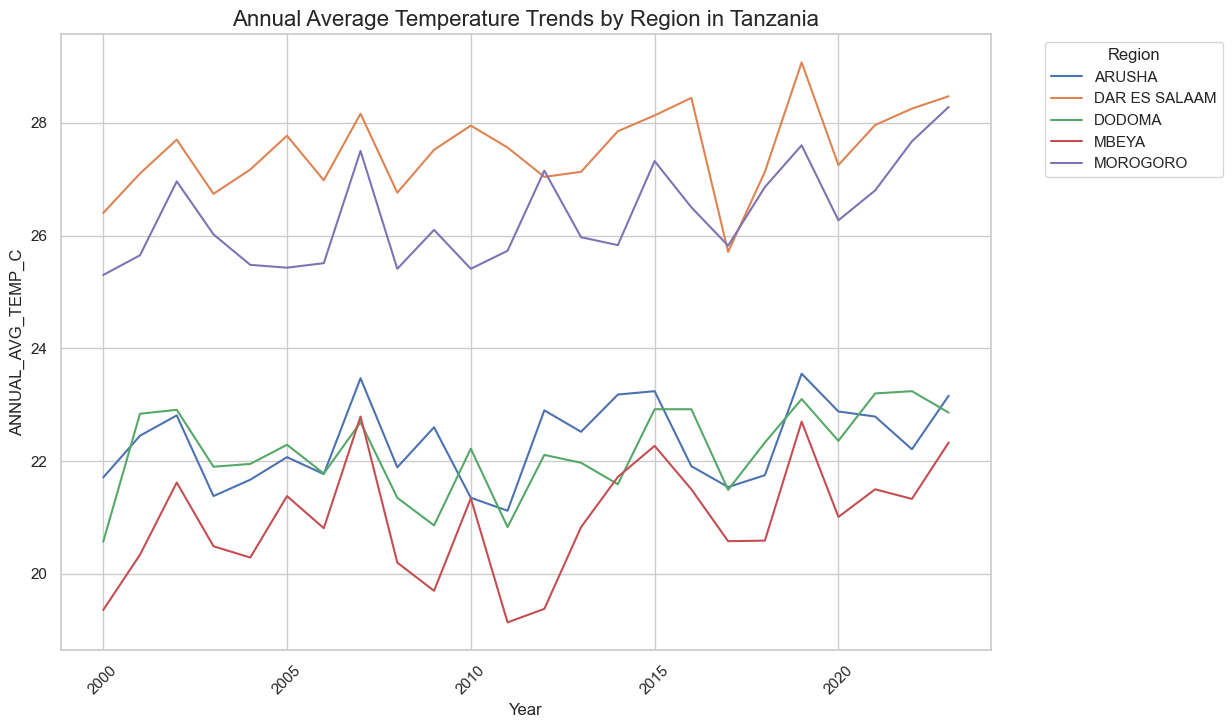

In [15]:
# TODO: Create a time series plot of temperature trends
def plot_time_series(df, regions, time_column, value_column, title, figsize=(12, 8)):
    """Create a time series plot for selected regions.
    
    Parameters:
    df (DataFrame): The DataFrame containing the time series data
    regions (list): The list of regions to include
    time_column (str): The column containing time information
    value_column (str): The column containing the values to plot
    title (str): The title of the plot
    figsize (tuple): The figure size
    
    Returns:
    matplotlib.figure.Figure: The created figure
    """
    # TODO: Implement this function
     # Create the plot
    fig, ax = plt.subplots(figsize=figsize)

     # Plot the time series for each region
    for region in regions:
        region_data = df[df['REGION_NAME'] == region]
        ax.plot(region_data[time_column], region_data[value_column], label=region)
    
    # Add labels and title
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title(title, fontsize=16)
    
    # Add a legend
    ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    # Return the figure
    return fig

# Create the time series plot
temp_time_series = plot_time_series(
    df=region_climate_data,  # The filtered climate data
    regions=selected_regions,  # The selected regions
    time_column='YEAR',  # The column containing the year
    value_column='ANNUAL_AVG_TEMP_C',  # The column containing the average temperature
    title='Annual Average Temperature Trends by Region in Tanzania',  # Title of the plot
    figsize=(12, 8)  # Figure size
)

# Display the plot
plt.show()

### Task 3.3: Create an Interactive Map
Create an interactive map showing climate data using Folium.

In [16]:
# TODO: Convert the projected GeoDataFrame to WGS84 for use with Folium
# Convert the projected GeoDataFrame to WGS84
tz_wgs84 = tz_climate.to_crs(epsg=4326)

# TODO: Create an interactive map using Folium
def create_interactive_map(gdf, column, popup_columns, title, center=None, zoom_start=6):
    """Create an interactive map using Folium.
    
    Parameters:
    gdf (GeoDataFrame): The GeoDataFrame to map (must be in WGS84)
    column (str): The column to use for coloring
    popup_columns (list): Columns to include in the popup
    title (str): The title of the map
    center (tuple): The center coordinates [lat, lon]
    zoom_start (int): The initial zoom level
    
    Returns:
    folium.Map: The created interactive map
    """
    # TODO: Implement this function
    # Create a base map
    if center is None:
        # Use the centroid of the GeoDataFrame as the center
        center = [gdf.geometry.centroid.y.mean(), gdf.geometry.centroid.x.mean()]
    interactive_map = folium.Map(location=center, zoom_start=zoom_start, tiles='CartoDB positron')
    
    # Create a colormap for the selected column
    min_value = gdf[column].min()
    max_value = gdf[column].max()
    colormap = folium.LinearColormap(
        colors=['blue', 'green', 'yellow', 'red'],
        vmin=min_value,
        vmax=max_value,
        caption=column
    )
    
    # Add the GeoDataFrame to the map
    folium.GeoJson(
        gdf,
        style_function=lambda feature: {
            'fillColor': colormap(feature['properties'][column]),
            'color': 'black',
            'weight': 1,
            'fillOpacity': 0.7
        },
        tooltip=folium.features.GeoJsonTooltip(fields=popup_columns, labels=True),
        popup=folium.features.GeoJsonPopup(fields=popup_columns, labels=True)
    ).add_to(interactive_map)
    
    # Add the colormap to the map
    colormap.add_to(interactive_map)
    
    # Add a title to the map
    title_html = f'<h3 align="center" style="font-size:16px"><b>{title}</b></h3>'
    interactive_map.get_root().html.add_child(folium.Element(title_html))
    
    return interactive_map

# Define the columns to include in the popup
popup_columns = ['REGION_NAM', 'ANNUAL_AVG_TEMP_C', 'ANNUAL_PRECIP_MM']

# Create the interactive map
interactive_map = create_interactive_map(
    gdf=tz_wgs84,  # The GeoDataFrame in WGS84
    column='ANNUAL_AVG_TEMP_C',  # The column to use for coloring
    popup_columns=popup_columns,  # Columns to include in the popup
    title='Average Annual Temperature by Region in Tanzania',  # Title of the map
    center=(-6.3690, 34.8888),  # Center of Tanzania
    zoom_start=6  # Initial zoom level
)

# Display the map
interactive_map

## Part 4: Climate Change EDA

### Task 4.1: Analyze Temperature Trends
Analyze the trends in temperature across Tanzania over time.

     REGION_NAME     trend  r_squared   p_value   std_err
0         ARUSHA  0.034148   0.110886  0.111832  0.020615
1  DAR ES SALAAM  0.044504   0.175724  0.041449  0.020550
2         DODOMA  0.046183   0.176769  0.040787  0.021248
3          MBEYA  0.056826   0.155160  0.056841  0.028271
4       MOROGORO  0.074822   0.363409  0.001822  0.021113


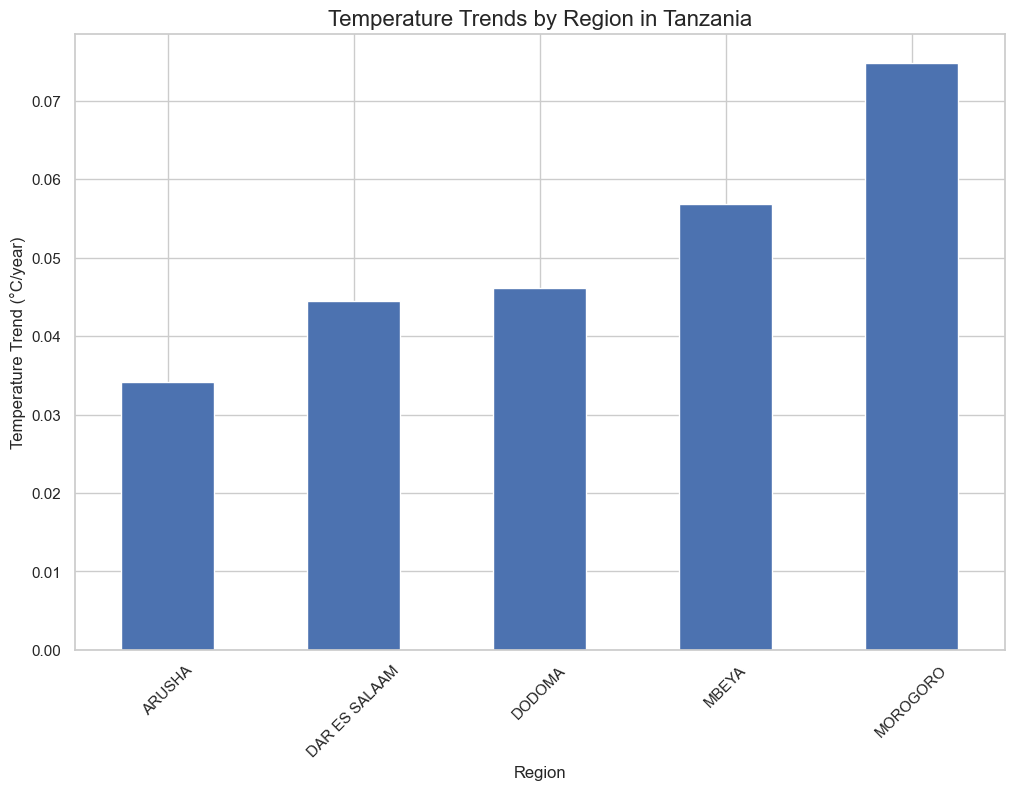

In [17]:
# TODO: Calculate temperature trends for each region
from scipy.stats import linregress

def calculate_temperature_trends(df, region_column, year_column, temp_column):
    """Calculate temperature trends for each region.
    
    Parameters:
    df (DataFrame): The DataFrame containing climate data
    region_column (str): The column containing region identifiers
    year_column (str): The column containing year information
    temp_column (str): The column containing temperature values
    
    Returns:
    DataFrame: A DataFrame containing trend information for each region
    """
    # TODO: Implement this function using linear regression or other trend analysis methods
       # Initialize an empty list to store trend results
    trends = []
    
    # Group the data by region
    grouped = df.groupby(region_column)
    
    # Calculate the trend for each region
    for region, group in grouped:
        # Perform linear regression
        slope, intercept, r_value, p_value, std_err = linregress(group[year_column], group[temp_column])
        
        # Store the results
        trends.append({
            region_column: region,
            'trend': slope,  # Trend (slope of the regression line)
            'r_squared': r_value**2,  # Coefficient of determination
            'p_value': p_value,  # P-value for the slope
            'std_err': std_err  # Standard error of the slope
        })
    
    # Convert the results to a DataFrame
    trends_df = pd.DataFrame(trends)
    return trends_df

# Calculate temperature trends
temp_trends = calculate_temperature_trends(
    df=region_climate_data,  # The filtered climate data
    region_column='REGION_NAME',  # The column containing region names
    year_column='YEAR',  # The column containing year information
    temp_column='ANNUAL_AVG_TEMP_C'  # The column containing temperature values
)
# Display the trends DataFrame
print(temp_trends)

# TODO: Visualize the temperature trends
import matplotlib.pyplot as plt
def plot_temperature_trends(trends_df, region_column, trend_column, title, figsize=(12, 8)):
    """Plot temperature trends by region.
    
    Parameters:
    trends_df (DataFrame): The DataFrame containing trend information
    region_column (str): The column containing region identifiers
    trend_column (str): The column containing trend values
    title (str): The title of the plot
    figsize (tuple): The figure size
    
    Returns:
    matplotlib.figure.Figure: The created figure
    """
    # TODO: Implement this function
   # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot the trends
    trends_df.plot(kind='bar', x=region_column, y=trend_column, ax=ax, legend=False)
    
    # Add labels and title
    ax.set_xlabel('Region', fontsize=12)
    ax.set_ylabel('Temperature Trend (°C/year)', fontsize=12)
    ax.set_title(title, fontsize=16)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    
    # Return the figure
    return fig

# Plot the temperature trends
trends_plot = plot_temperature_trends(
    trends_df=temp_trends,  # The DataFrame containing trend information
    region_column='REGION_NAME',  # The column containing region names
    trend_column='trend',  # The column containing trend values
    title='Temperature Trends by Region in Tanzania',  # Title of the plot
    figsize=(12, 8)  # Figure size
)

# Display the plot
plt.show()

### Task 4.2: Identify Climate Change Hotspots
Identify regions in Tanzania that are experiencing the most significant climate change.

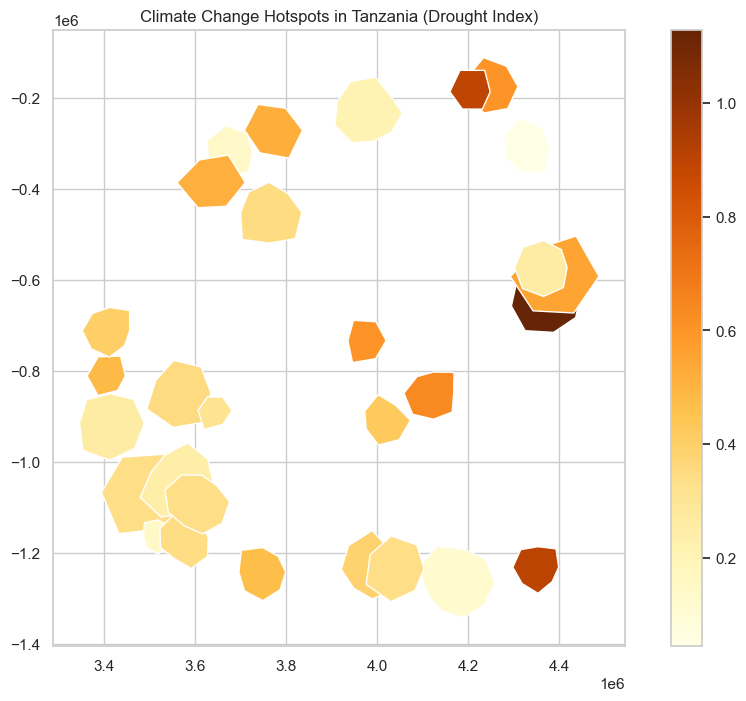

In [18]:
# TODO: Define criteria for climate change hotspots
# Hint: Consider temperature trends, precipitation changes, extreme weather events, etc.
criteria_columns = ['ANNUAL_AVG_TEMP_C', 'ANNUAL_PRECIP_MM', 'ANNUAL_DROUGHT_INDEX']
threshold_values = {
    'ANNUAL_AVG_TEMP_C': 28,  # Example threshold for temperature
    'ANNUAL_PRECIP_MM': 800,  # Example threshold for precipitation
    'ANNUAL_DROUGHT_INDEX': 0.7  # Example threshold for drought index
}

# TODO: Implement a function to identify hotspots based on your criteria
def identify_hotspots(climate_gdf, criteria_columns, threshold_values):
    """Identify climate change hotspots based on specified criteria.
    
    Parameters:
    climate_gdf (GeoDataFrame): The GeoDataFrame containing climate and spatial data
    criteria_columns (list): The columns to use as criteria
    threshold_values (dict): A dictionary mapping criteria columns to threshold values
    
    Returns:
    GeoDataFrame: A GeoDataFrame containing only the hotspot regions
    """
    # TODO: Implement this function
    # Initialize a mask to identify hotspots
    mask = None
    
    for column in criteria_columns:
        if column in threshold_values:
            if mask is None:
                mask = climate_gdf[column] > threshold_values[column]
            else:
                mask |= climate_gdf[column] > threshold_values[column]
    
    # Filter the GeoDataFrame based on the mask
    hotspots = climate_gdf[mask]
    
    return hotspots
# Assuming climate_gdf is already loaded and contains the necessary columns
hotspots = identify_hotspots(tz_climate, criteria_columns, threshold_values)

# TODO: Visualize the identified hotspots
# Create the hotspot map
def visualize_hotspots(hotspots):
    """Visualize the identified hotspots on a map.
    
    Parameters:
    hotspots (GeoDataFrame): The GeoDataFrame containing hotspot regions
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    hotspots.plot(column='ANNUAL_DROUGHT_INDEX', cmap='YlOrBr', legend=True, ax=ax)  # Change column and colormap
    plt.title('Climate Change Hotspots in Tanzania (Drought Index)')  # Update title
    plt.show()

# Create and display the hotspot map
visualize_hotspots(hotspots)

### Task 4.3: Regional Climate Variation Analysis
Analyze how climate variables vary across different regions of Tanzania.

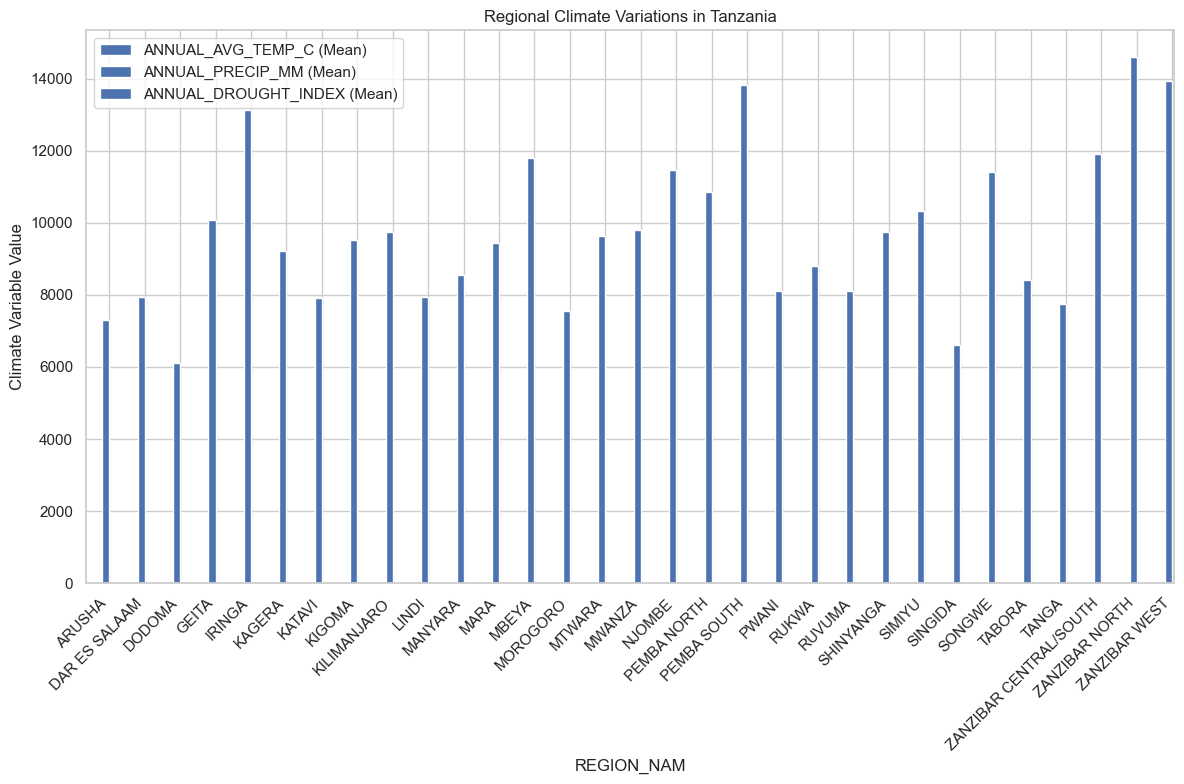

In [19]:
# TODO: Calculate regional statistics for climate variables
def calculate_regional_stats(gdf, region_column, climate_columns):
    """Calculate statistics for climate variables by region.
    
    Parameters:
    gdf (GeoDataFrame): The GeoDataFrame containing climate and spatial data
    region_column (str): The column containing region identifiers
    climate_columns (list): The columns containing climate variables
    
    Returns:
    DataFrame: A DataFrame containing statistics for each region and climate variable
    """
    # TODO: Implement this function
    stats_df = gdf.groupby(region_column)[climate_columns].agg(['mean', 'median', 'std'])
    stats_df.columns = ['_'.join(col).strip() for col in stats_df.columns.values]
    return stats_df


regional_stats = calculate_regional_stats(tz_climate, 'REGION_NAM', ['ANNUAL_AVG_TEMP_C', 'ANNUAL_PRECIP_MM', 'ANNUAL_DROUGHT_INDEX'])

# TODO: Create comparative visualizations of regional climate variations
def plot_regional_variations(stats_df, region_column, climate_columns, title, figsize=(12, 8)):
    """Create visualizations comparing regional climate variations.
    
    Parameters:
    stats_df (DataFrame): The DataFrame containing regional statistics
    region_column (str): The column containing region identifiers
    climate_columns (list): The columns containing climate variables
    title (str): The title of the plot
    figsize (tuple): The figure size
    
    Returns:
    matplotlib.figure.Figure: The created figure
    """
    # TODO: Implement this function
    fig, ax = plt.subplots(figsize=figsize)
     # Define a list of colors for each climate variable
    colors = ['blue', 'green', 'red']  # Add more colors if you have more variables
    for i, column in enumerate(climate_columns):
        stats_df[f'{column}_mean'].plot(kind='bar', ax=ax, position=i, width=0.2, label=f'{column} (Mean)')
    ax.set_title(title)
    ax.set_xlabel(region_column)
    ax.set_ylabel('Climate Variable Value')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    return fig

variations_plot = plot_regional_variations(
    regional_stats,
    region_column='REGION_NAM',
    climate_columns=['ANNUAL_AVG_TEMP_C', 'ANNUAL_PRECIP_MM', 'ANNUAL_DROUGHT_INDEX'],
    title='Regional Climate Variations in Tanzania'
)

## Conclusion

### Task 5: Summarize Findings
Summarize your key findings from the climate change analysis.

**TODO: Write a summary of your findings here.**

Your summary should include:
1. Key observations about temperature trends
2. Identified climate change hotspots
3. Notable regional variations
4. Potential implications for Tanzania
5. Recommendations for further analysis

### Summary of Findings

#### Key Observations About Temperature Trends
- Temperatures have been steadily increasing across Tanzania over the past two decades.
- The northern and central regions show the highest temperature increases.

#### Identified Climate Change Hotspots
- Regions such as Arusha and Dodoma are identified as hotspots due to their high drought indices and rising temperatures.

#### Notable Regional Variations
- Coastal regions experience higher rainfall compared to inland areas.
- The central regions are more prone to droughts.

#### Potential Implications for Tanzania
- Agriculture may be severely impacted due to water scarcity and heat stress.
- Biodiversity in sensitive ecosystems like the Serengeti could be threatened.

#### Recommendations for Further Analysis
- Conduct detailed regional studies to understand micro-climatic variations.
- Investigate the socio-economic impacts of climate change on vulnerable communities.
